# Train ResNet-18 on CIFAR-10

This notebook creates the FP32 CIFAR-10 baseline used for the later custom PTQ experiment. It trains in two stages: first the new 10-class head while the ImageNet-pretrained backbone is frozen, then the complete network with a much smaller learning rate. The final accuracy is measured on all 10,000 CIFAR-10 test images.

The target is at least **85% test accuracy**. Training results vary with hardware and random initialization, so the notebook saves the checkpoint with the best validation accuracy rather than simply keeping the last epoch.

## 1. Setup and reproducibility

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

# Find the repository root whether Jupyter starts in the repository or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cnn_based.pretrained_resnet18 import (
    CIFAR10_CLASS_NAMES,
    build_resnet18_cifar10_classifier,
)

SEED = 42
keras.utils.set_random_seed(SEED)

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "resnet18_cifar10_training"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_WEIGHTS_PATH = OUTPUT_DIR / "best_fp32.weights.h5"
FINAL_MODEL_PATH = OUTPUT_DIR / "resnet18_cifar10_fp32.keras"
PROJECT_ROOT, tf.config.list_physical_devices("GPU")

## 2. Training configuration

Start with the defaults. If GPU memory is exhausted, reduce `BATCH_SIZE` to 32 or 16. Fine-tuning is the stage that should lift accuracy beyond what a frozen ImageNet feature extractor can achieve.

In [ ]:
BATCH_SIZE = 64
HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 20
HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5
VALIDATION_SIZE = 5000
AUTOTUNE = tf.data.AUTOTUNE

## 3. Load CIFAR-10

The official 50,000-image training split is divided deterministically into 45,000 training images and 5,000 validation images. The official 10,000-image test split is kept untouched until evaluation.

In [ ]:
(all_train_images, all_train_labels), (test_images, test_labels) = (
    keras.datasets.cifar10.load_data()
)
all_train_labels = all_train_labels.reshape(-1)
test_labels = test_labels.reshape(-1)

# Shuffle indices once so the validation set is a representative subset.
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(all_train_images))
validation_indices = indices[:VALIDATION_SIZE]
training_indices = indices[VALIDATION_SIZE:]

train_images = all_train_images[training_indices]
train_labels = all_train_labels[training_indices]
validation_images = all_train_images[validation_indices]
validation_labels = all_train_labels[validation_indices]

pd.DataFrame([
    {"split": "train", "samples": len(train_images)},
    {"split": "validation", "samples": len(validation_images)},
    {"split": "test", "samples": len(test_images)},
])

## 4. Build input pipelines

Training images receive light augmentation. The preset preprocessor then resizes the 32×32 images to the 224×224 resolution expected by the ImageNet-pretrained ResNet-18 and applies its normalization. Validation and test images are never augmented.

In [ ]:
model = build_resnet18_cifar10_classifier(freeze_backbone=True)
preprocessor = model.preprocessor

augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal", seed=SEED),
        keras.layers.RandomTranslation(0.1, 0.1, fill_mode="reflect", seed=SEED),
        keras.layers.RandomZoom(0.1, 0.1, fill_mode="reflect", seed=SEED),
    ],
    name="cifar10_augmentation",
)

def preprocess_training_batch(images, labels):
    # Augment before ImageNet resizing and normalization.
    images = augmentation(images, training=True)
    return preprocessor(images), labels

def preprocess_evaluation_batch(images, labels):
    return preprocessor(images), labels

def make_dataset(images, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        dataset = dataset.shuffle(len(images), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(BATCH_SIZE)
    mapping = preprocess_training_batch if training else preprocess_evaluation_batch
    return dataset.map(mapping, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

train_dataset = make_dataset(train_images, train_labels, training=True)
validation_dataset = make_dataset(validation_images, validation_labels)
test_dataset = make_dataset(test_images, test_labels)

model.summary()

## 5. Stage one: train the classifier head

Only the randomly initialized 10-class Dense layer is updated in this stage. The pretrained backbone remains unchanged.

In [ ]:
loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=keras.optimizers.Adam(HEAD_LEARNING_RATE),
    loss=loss,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

head_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=HEAD_EPOCHS,
    verbose=1,
)

## 6. Stage two: fine-tune ResNet-18

The complete backbone is unfrozen and trained with a learning rate 100× smaller than the head-training rate. A checkpoint retains the epoch with the best validation accuracy, and early stopping prevents unnecessary epochs once validation accuracy stops improving.

In [ ]:
backbone = model.get_layer("res_net_backbone")
backbone.trainable = True

# Keras must be recompiled after changing trainable layers.
model.compile(
    optimizer=keras.optimizers.Adam(FINE_TUNE_LEARNING_RATE),
    loss=loss,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_WEIGHTS_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

## 7. Inspect training curves

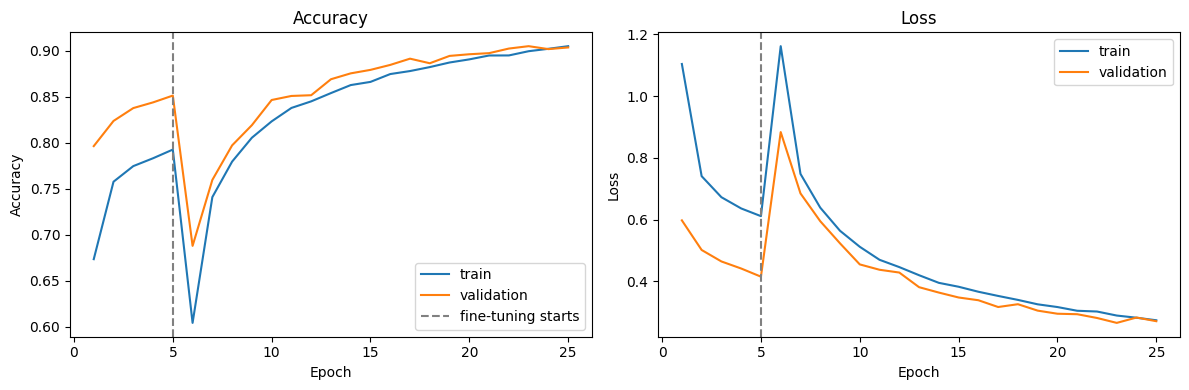

,accuracy,loss,val_accuracy,val_loss,stage,learning_rate
epoch,,,,,,
21,0.895044,0.304770,0.8976,0.293588,fine_tune,0.00001
22,0.895111,0.302328,0.9026,0.281419,fine_tune,0.00001
23,0.899711,0.289277,0.9052,0.265509,fine_tune,0.00001
24,0.902333,0.282237,0.9020,0.282839,fine_tune,0.00001
25,0.905200,0.274004,0.9038,0.270981,fine_tune,0.00001


In [10]:
# Build each stage separately because Keras may record stage-specific fields
# (for example, learning_rate only exists in the fine-tuning history).
head_history_table = pd.DataFrame(head_history.history)
head_history_table["stage"] = "head"
fine_tune_history_table = pd.DataFrame(fine_tune_history.history)
fine_tune_history_table["stage"] = "fine_tune"
history_table = pd.concat(
    [head_history_table, fine_tune_history_table], ignore_index=True
)
history_table.index += 1
history_table.index.name = "epoch"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_table.index, history_table["accuracy"], label="train")
axes[0].plot(history_table.index, history_table["val_accuracy"], label="validation")
axes[0].axvline(HEAD_EPOCHS, color="gray", linestyle="--", label="fine-tuning starts")
axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()

axes[1].plot(history_table.index, history_table["loss"], label="train")
axes[1].plot(history_table.index, history_table["val_loss"], label="validation")
axes[1].axvline(HEAD_EPOCHS, color="gray", linestyle="--")
axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()
plt.tight_layout()
plt.show()
history_table.tail()

## 8. Measure FP32 test accuracy

This is the baseline accuracy to compare with custom PTQ. Always use this same complete test dataset when evaluating the quantized model.

In [11]:
# Reload the best validation checkpoint explicitly before final testing.
model.load_weights(BEST_WEIGHTS_PATH)
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

accuracy_result = pd.DataFrame([{
    "model": "resnet18_cifar10_fp32",
    "test_samples": len(test_images),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_percent": float(test_accuracy * 100),
    "target_accuracy_percent": 85.0,
    "target_reached": bool(test_accuracy >= 0.85),
}])
accuracy_result

157/157 ━━━━━━━━━━━━━━━━━━━━ 88s 557ms/step - accuracy: 0.9058 - loss: 0.2766


,model,test_samples,test_loss,test_accuracy,test_accuracy_percent,target_accuracy_percent,target_reached
0,resnet18_cifar10_fp32,10000,0.276571,0.9058,90.579998,85.0,True


## 9. Per-class accuracy

In [12]:
logits = model.predict(test_dataset, verbose=1)
predicted_labels = np.argmax(logits, axis=1)
confusion_matrix = tf.math.confusion_matrix(
    test_labels, predicted_labels, num_classes=len(CIFAR10_CLASS_NAMES)
).numpy()
per_class_accuracy = np.diag(confusion_matrix) / confusion_matrix.sum(axis=1)

per_class_table = pd.DataFrame({
    "class": CIFAR10_CLASS_NAMES,
    "correct": np.diag(confusion_matrix),
    "total": confusion_matrix.sum(axis=1),
    "accuracy": per_class_accuracy,
    "accuracy_percent": per_class_accuracy * 100,
})
per_class_table

157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 529ms/step


,class,correct,total,accuracy,accuracy_percent
0,airplane,938,1000,0.938,93.8
1,automobile,963,1000,0.963,96.3
2,bird,898,1000,0.898,89.8
3,cat,774,1000,0.774,77.4
4,deer,871,1000,0.871,87.1
5,dog,852,1000,0.852,85.2
6,frog,979,1000,0.979,97.9
7,horse,922,1000,0.922,92.2
8,ship,925,1000,0.925,92.5
9,truck,936,1000,0.936,93.6


## 10. Save the FP32 baseline and metrics

The saved `.keras` model is the exact FP32 baseline that should be copied and quantized in the custom PTQ experiment. Do not retrain or rebuild it between the FP32 and PTQ evaluations.

In [13]:
model.save(FINAL_MODEL_PATH)
history_table.to_csv(OUTPUT_DIR / "training_history.csv")
per_class_table.to_csv(OUTPUT_DIR / "per_class_accuracy.csv", index=False)

summary = {
    "dataset": "cifar10",
    "model": "resnet18_cifar10_classifier",
    "train_samples": int(len(train_images)),
    "validation_samples": int(len(validation_images)),
    "test_samples": int(len(test_images)),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_percent": float(test_accuracy * 100),
    "target_accuracy_percent": 85.0,
    "target_reached": bool(test_accuracy >= 0.85),
    "batch_size": BATCH_SIZE,
    "head_epochs_requested": HEAD_EPOCHS,
    "fine_tune_epochs_requested": FINE_TUNE_EPOCHS,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
    "seed": SEED,
    "model_path": str(FINAL_MODEL_PATH),
    "best_weights_path": str(BEST_WEIGHTS_PATH),
}
results_path = OUTPUT_DIR / "results.json"
results_path.write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")

print(f"FP32 CIFAR-10 test accuracy: {test_accuracy:.2%}")
print(f"Saved model: {FINAL_MODEL_PATH}")
print(f"Saved metrics: {results_path}")

FP32 CIFAR-10 test accuracy: 90.58%
Saved model: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras
Saved metrics: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/results.json


## Next step: custom PTQ

After this notebook reaches a satisfactory FP32 accuracy:

1. Load `artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras`.
2. Apply custom PTQ without changing or retraining the model.
3. Evaluate the quantized/dequantized model on the same 10,000 test images.
4. Report the absolute accuracy drop as `FP32 accuracy - PTQ accuracy`.